<a href="https://colab.research.google.com/github/Ayushi-Manjapara/CSCI218-Rice-Classification-Grp-14/blob/main/AI-Grp14-Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Rice Classification using Machine Learning  

### Dataset:
Rice (Cammeo and Osmancik) – UCI Machine Learning Repository  

### Objective:
To build and compare multiple machine learning models to classify rice grains
into two species based on morphological features.

## Install & Imports

In [3]:
!pip install ucimlrepo

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

# Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.model_selection import learning_curve, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                             precision_score, recall_score, f1_score, roc_curve,
                             auc, roc_auc_score, precision_recall_curve)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

## Dataset Description

The dataset contains 3810 rice grain samples belonging to two species:

- Cammeo
- Osmancik

Each sample contains 7 real-valued morphological features extracted from images:

- Area
- Perimeter
- Major Axis Length
- Minor Axis Length
- Eccentricity
- Convex Area
- Extent

Task: Binary Classification

In [4]:
rice = fetch_ucirepo(id=545)

X = rice.data.features
y = rice.data.targets

print("Dataset Shape:", X.shape)
print("\nClass Distribution:\n", y.value_counts())

Dataset Shape: (3810, 7)

Class Distribution:
 Class   
Osmancik    2180
Cammeo      1630
Name: count, dtype: int64


## Dataset information

In [5]:
print(f"Total samples: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")
print(f"\nFeature names: {list(X.columns)}")
print(f"\nTarget variable: {y.columns[0]}")
print(f"Classes: {y['Class'].unique()}")

Total samples: 3810
Number of features: 7

Feature names: ['Area', 'Perimeter', 'Major_Axis_Length', 'Minor_Axis_Length', 'Eccentricity', 'Convex_Area', 'Extent']

Target variable: Class
Classes: ['Cammeo' 'Osmancik']


In [6]:
print(X.describe())

               Area    Perimeter  Major_Axis_Length  Minor_Axis_Length  \
count   3810.000000  3810.000000        3810.000000        3810.000000   
mean   12667.727559   454.239180         188.776222          86.313750   
std     1732.367706    35.597081          17.448679           5.729817   
min     7551.000000   359.100006         145.264465          59.532406   
25%    11370.500000   426.144752         174.353855          82.731695   
50%    12421.500000   448.852493         185.810059          86.434647   
75%    13950.000000   483.683746         203.550438          90.143677   
max    18913.000000   548.445984         239.010498         107.542450   

       Eccentricity   Convex_Area       Extent  
count   3810.000000   3810.000000  3810.000000  
mean       0.886871  12952.496850     0.661934  
std        0.020818   1776.972042     0.077239  
min        0.777233   7723.000000     0.497413  
25%        0.872402  11626.250000     0.598862  
50%        0.889050  12706.500000     0

### Check for missing values

In [7]:
print(X.isnull().sum())
print(f"\nTotal missing values: {X.isnull().sum().sum()}")

Area                 0
Perimeter            0
Major_Axis_Length    0
Minor_Axis_Length    0
Eccentricity         0
Convex_Area          0
Extent               0
dtype: int64

Total missing values: 0


### Check for duplicates

In [8]:
print(f"Duplicate rows: {X.duplicated().sum()}")

Duplicate rows: 0


### Data types

In [9]:
print(X.dtypes)

Area                   int64
Perimeter            float64
Major_Axis_Length    float64
Minor_Axis_Length    float64
Eccentricity         float64
Convex_Area            int64
Extent               float64
dtype: object


## Train-Test Split

The dataset is split into:

- 80% Training data
- 20% Testing data
- Stratified sampling is used to preserve class distribution

This ensures:
- Balanced representation of both rice species
- Fair evaluation on unseen data

In [10]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Display shapes
print("Training Set Shape:", X_train.shape)
print("Testing Set Shape:", X_test.shape)

# Display percentage split
total_samples = len(X)
train_percentage = len(X_train) / total_samples * 100
test_percentage = len(X_test) / total_samples * 100

print(f"\nTraining Percentage: {train_percentage:.2f}%")
print(f"Testing Percentage: {test_percentage:.2f}%")

# Display class distribution
print("\nTraining Class Distribution:")
print(y_train.value_counts())

print("\nTesting Class Distribution:")
print(y_test.value_counts())


Training Set Shape: (3048, 7)
Testing Set Shape: (762, 7)

Training Percentage: 80.00%
Testing Percentage: 20.00%

Training Class Distribution:
Class   
Osmancik    1744
Cammeo      1304
Name: count, dtype: int64

Testing Class Distribution:
Class   
Osmancik    436
Cammeo      326
Name: count, dtype: int64


## Feature Scaling

In [11]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Feature means after scaling: {X_train_scaled.mean(axis=0).round(10)}")
print(f"Feature stds after scaling: {X_train_scaled.std(axis=0).round(2)}")

Feature means after scaling: [ 0. -0. -0. -0. -0.  0.  0.]
Feature stds after scaling: [1. 1. 1. 1. 1. 1. 1.]


## Selected Models

The following models were selected for comparison:

1. Logistic Regression – Linear baseline model
2. K-Nearest Neighbors – Distance-based classifier
3. Support Vector Machine (RBF) – Non-linear classifier
4. Random Forest – Ensemble tree-based model

## Define the Models

In [12]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),
    "SVM (RBF Kernel)": SVC(kernel='rbf', probability=True),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}


## Training + Evaluation

In [13]:
results = []

for name, model in models.items():

    if name in ["Logistic Regression", "KNN (k=5)", "SVM (RBF Kernel)"]:
        model.fit(X_train_scaled, y_train.values.ravel())
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train.values.ravel())
        y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    results.append([name, acc, precision, recall, f1])

    print("\n==============================")
    print(name)
    print("==============================")
    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred))



Logistic Regression
Accuracy: 0.916010498687664
              precision    recall  f1-score   support

      Cammeo       0.92      0.88      0.90       326
    Osmancik       0.92      0.94      0.93       436

    accuracy                           0.92       762
   macro avg       0.92      0.91      0.91       762
weighted avg       0.92      0.92      0.92       762


KNN (k=5)
Accuracy: 0.9094488188976378
              precision    recall  f1-score   support

      Cammeo       0.91      0.88      0.89       326
    Osmancik       0.91      0.93      0.92       436

    accuracy                           0.91       762
   macro avg       0.91      0.91      0.91       762
weighted avg       0.91      0.91      0.91       762


SVM (RBF Kernel)
Accuracy: 0.910761154855643
              precision    recall  f1-score   support

      Cammeo       0.91      0.87      0.89       326
    Osmancik       0.91      0.94      0.92       436

    accuracy                           0.91    

## Cross Validation

In [14]:
for name, model in models.items():

    if name in ["Logistic Regression", "KNN (k=5)", "SVM (RBF Kernel)"]:
        scores = cross_val_score(model, X_train_scaled, y_train.values.ravel(), cv=5)
    else:
        scores = cross_val_score(model, X_train, y_train.values.ravel(), cv=5)

    print(f"{name} CV Accuracy: {scores.mean():.4f}")

Logistic Regression CV Accuracy: 0.9324
KNN (k=5) CV Accuracy: 0.9242
SVM (RBF Kernel) CV Accuracy: 0.9318
Random Forest CV Accuracy: 0.9245


## Confusion Matrices

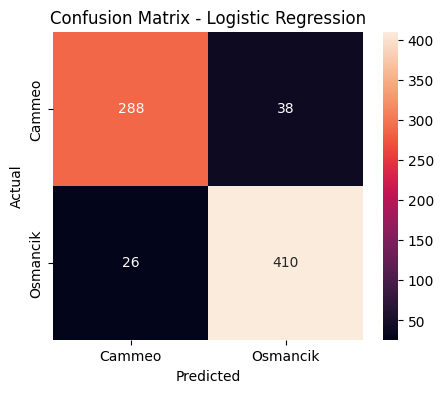

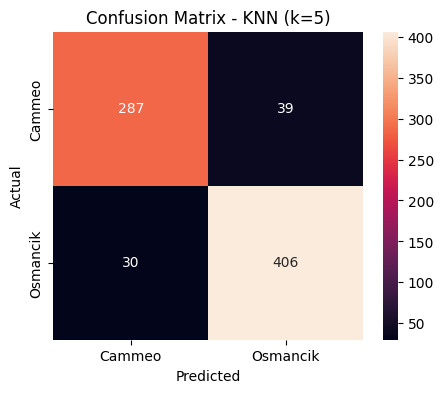

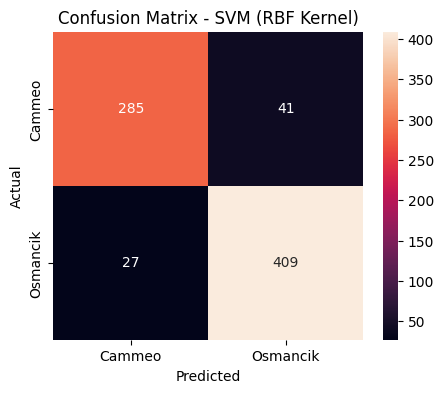

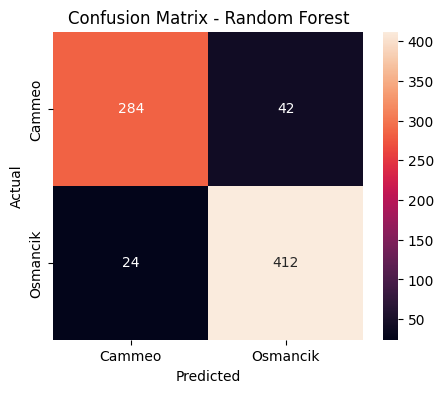

In [15]:
for name, model in models.items():

    if name in ["Logistic Regression", "KNN (k=5)", "SVM (RBF Kernel)"]:
        y_pred = model.predict(X_test_scaled)
    else:
        y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=["Cammeo", "Osmancik"],
                yticklabels=["Cammeo", "Osmancik"])

    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

## ROC Curve

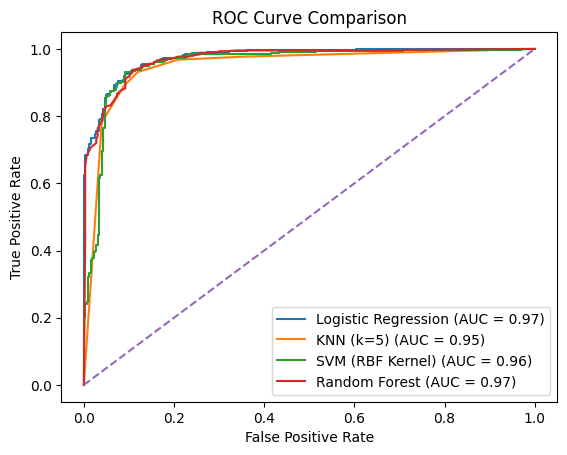

In [16]:
plt.figure()

for name, model in models.items():

    if name == "Dummy (Baseline)":
        continue

    if name in ["Logistic Regression", "KNN (k=5)", "SVM (RBF Kernel)"]:
        y_prob = model.predict_proba(X_test_scaled)[:,1]
    else:
        y_prob = model.predict_proba(X_test)[:,1]

    fpr, tpr, _ = roc_curve(y_test, y_prob, pos_label="Osmancik")
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()


## Model Comparison Table

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.916010   0.916042  0.916010  0.915793
1            KNN (k=5)  0.909449   0.909366  0.909449  0.909278
2     SVM (RBF Kernel)  0.910761   0.910845  0.910761  0.910487
3        Random Forest  0.913386   0.913730  0.913386  0.913032


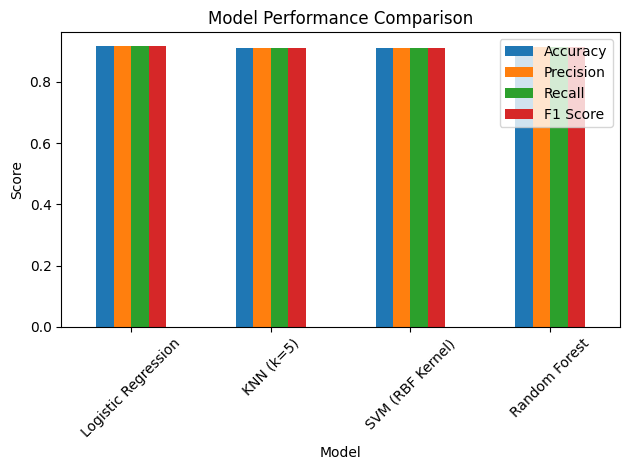

In [17]:
results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"]
)

print(results_df)

results_df.set_index("Model").plot(kind='bar')
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Hyperparameter Tuning

To improve model performance, we apply **Grid Search with Cross-Validation (GridSearchCV)**
to all classification models.

### Tuning Method Used: GridSearchCV

Grid Search:
- Systematically tests multiple combinations of hyperparameters
- Uses 5-fold cross-validation (cv = 5)
- Selects the best parameter combination based on accuracy score
- Reduces overfitting and improves generalization

### Models Tuned

The following models are tuned:

1. Logistic Regression  
   - Parameters tuned: C, solver, penalty  

2. k-Nearest Neighbors (kNN)  
   - Parameters tuned: n_neighbors, weights, metric  

3. Support Vector Machine (SVM)  
   - Parameters tuned: C, kernel, gamma  

4. Random Forest  
   - Parameters tuned: n_estimators, max_depth, min_samples_split, min_samples_leaf  


**Logistic Regression**

In [18]:
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs'],
    'penalty': ['l2']
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=500),
    param_grid_lr,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_lr.fit(X_train, y_train)

print("Logistic Regression Best Parameters:", grid_lr.best_params_)
print("Best CV Accuracy:", grid_lr.best_score_)

best_lr = grid_lr.best_estimator_
y_pred_lr = best_lr.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))


Logistic Regression Best Parameters: {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV Accuracy: 0.9347088750706615
Test Accuracy: 0.9186351706036745
              precision    recall  f1-score   support

      Cammeo       0.93      0.88      0.90       326
    Osmancik       0.91      0.95      0.93       436

    accuracy                           0.92       762
   macro avg       0.92      0.91      0.92       762
weighted avg       0.92      0.92      0.92       762



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


**k-Nearest Neighbors**

In [19]:
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_knn.fit(X_train, y_train)

print("kNN Best Parameters:", grid_knn.best_params_)
print("Best CV Accuracy:", grid_knn.best_score_)

best_knn = grid_knn.best_estimator_
y_pred_knn = best_knn.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))


kNN Best Parameters: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'uniform'}
Best CV Accuracy: 0.9055134727718108
Test Accuracy: 0.8792650918635171
              precision    recall  f1-score   support

      Cammeo       0.89      0.82      0.85       326
    Osmancik       0.87      0.92      0.90       436

    accuracy                           0.88       762
   macro avg       0.88      0.87      0.88       762
weighted avg       0.88      0.88      0.88       762



/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


**Support Vector Machine**

In [20]:
param_grid_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

grid_svm = GridSearchCV(
    SVC(),
    param_grid_svm,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_svm.fit(X_train, y_train)

print("SVM Best Parameters:", grid_svm.best_params_)
print("Best CV Accuracy:", grid_svm.best_score_)

best_svm = grid_svm.best_estimator_
y_pred_svm = best_svm.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVM Best Parameters: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Best CV Accuracy: 0.9356935583730384
Test Accuracy: 0.9212598425196851
              precision    recall  f1-score   support

      Cammeo       0.92      0.89      0.91       326
    Osmancik       0.92      0.94      0.93       436

    accuracy                           0.92       762
   macro avg       0.92      0.92      0.92       762
weighted avg       0.92      0.92      0.92       762



**Random Forest**

In [21]:
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(),
    param_grid_rf,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print("Random Forest Best Parameters:", grid_rf.best_params_)
print("Best CV Accuracy:", grid_rf.best_score_)

best_rf = grid_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Random Forest Best Parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Best CV Accuracy: 0.9288050822363993
Test Accuracy: 0.9173228346456693
              precision    recall  f1-score   support

      Cammeo       0.93      0.88      0.90       326
    Osmancik       0.91      0.95      0.93       436

    accuracy                           0.92       762
   macro avg       0.92      0.91      0.91       762
weighted avg       0.92      0.92      0.92       762



## Baseline vs Optimized Comparison

                 Model  Baseline Accuracy  Tuned Accuracy  Improvement
0  Logistic Regression             0.9160          0.9186       0.0026
1                  KNN             0.9094          0.8793      -0.0301
2                  SVM             0.9108          0.9213       0.0105
3        Random Forest             0.9134          0.9173       0.0039


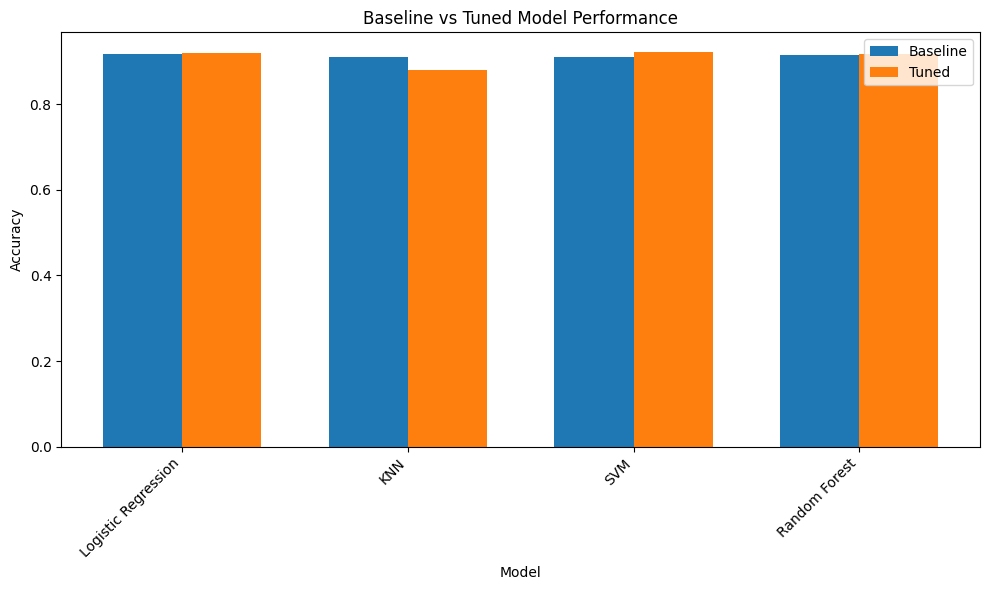

In [22]:
# Compare baseline vs tuned models
comparison_data = {
    'Model': ['Logistic Regression', 'KNN', 'SVM', 'Random Forest'],
    'Baseline Accuracy': [0.9160, 0.9094, 0.9108, 0.9134],  # from your baseline results
    'Tuned Accuracy': [0.9186, 0.8793, 0.9213, 0.9173],  # from your tuned results
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df['Improvement'] = comparison_df['Tuned Accuracy'] - comparison_df['Baseline Accuracy']

print(comparison_df)

# Visualize comparison
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(comparison_df))
width = 0.35

bars1 = ax.bar(x - width/2, comparison_df['Baseline Accuracy'], width, label='Baseline')
bars2 = ax.bar(x + width/2, comparison_df['Tuned Accuracy'], width, label='Tuned')

ax.set_xlabel('Model')
ax.set_ylabel('Accuracy')
ax.set_title('Baseline vs Tuned Model Performance')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Model'], rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

## Error Analysis

In [25]:
# Detailed Error Analysis on Best Model (choose best one - looks like SVM)
le = LabelEncoder()
y_test_encoded = le.fit_transform(y_test.values.ravel())
y_pred_encoded = le.transform(best_svm.predict(X_test))

# Find misclassified samples
misclassified_idx = np.where(y_pred_encoded != y_test_encoded)[0]
correctly_classified_idx = np.where(y_pred_encoded == y_test_encoded)[0]

print(f"Total test samples: {len(y_test)}")
print(f"Correctly classified: {len(correctly_classified_idx)} ({len(correctly_classified_idx)/len(y_test)*100:.2f}%)")
print(f"Misclassified: {len(misclassified_idx)} ({len(misclassified_idx)/len(y_test)*100:.2f}%)")

# Analyze misclassified samples
# Correct way
y_test_1d = y_test.values.ravel()  # or y_test.squeeze()
misclassified_samples['True_Class'] = y_test_1d[misclassified_idx]
misclassified_samples['Predicted_Class'] = best_svm.predict(X_test.iloc[misclassified_idx])


print("\nSample Misclassifications:")
print(misclassified_samples.head(10))

Total test samples: 762
Correctly classified: 702 (92.13%)
Misclassified: 60 (7.87%)

Sample Misclassifications:
      Area   Perimeter  Major_Axis_Length  Minor_Axis_Length  Eccentricity  \
0  13619.0  467.765991         193.680939          90.473480      0.884191   
1  12013.0  458.359009         195.082306          79.642708      0.912869   
2  12959.0  473.609985         206.225510          80.633575      0.920392   
3  12451.0  461.345001         191.407776          84.161499      0.898146   
4  15062.0  492.065002         198.027405          99.110664      0.865743   
5  13059.0  456.441010         185.982010          90.204483      0.874505   
6  12040.0  441.023010         182.752808          85.151146      0.884818   
7  13093.0  470.100006         197.197022          85.797287      0.900390   
8  13443.0  469.454010         196.638016          87.979149      0.894326   
9  11963.0  448.425995         191.077057          80.814232      0.906157   

   Convex_Area    Extent Tru

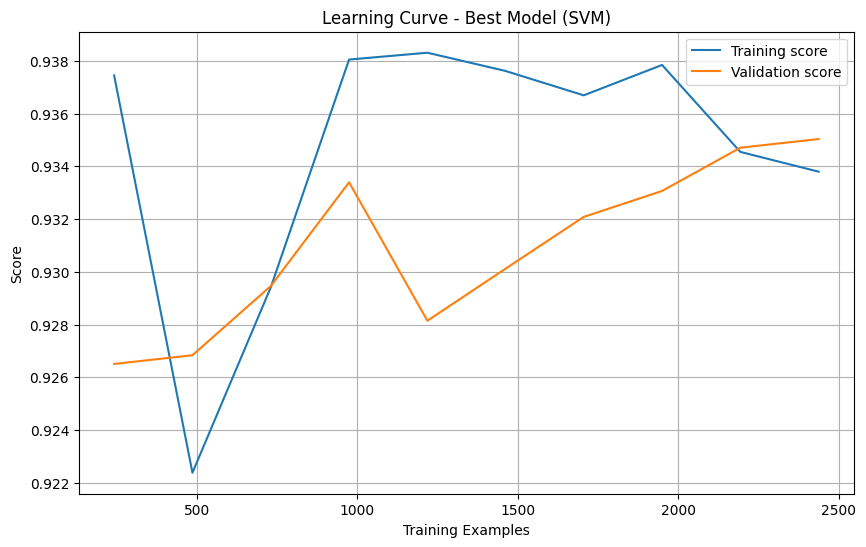

In [26]:
# Learning curve for best model
train_sizes, train_scores, val_scores = learning_curve(
    best_svm, X_train, y_train.values.ravel(),
    cv=5, n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10)
)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores.mean(axis=1), label='Training score')
plt.plot(train_sizes, val_scores.mean(axis=1), label='Validation score')
plt.xlabel('Training Examples')
plt.ylabel('Score')
plt.title('Learning Curve - Best Model (SVM)')
plt.legend()
plt.grid(True)
plt.show()